Isabel Garcia     
ig2303

In [100]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Problem 1 

(a)

In [3]:
fifa = pd.read_csv("shared/data/fifa22.csv")
fifa.head()

,name,rank,gender,wage_eur,log_wage,position,nationality,club,league,preferred_foot,shooting,passing,dribbling,defending,attacking,skill,movement,power,mentality,goalkeeping
0,Lionel Andrés Messi Cuccittini,93,M,320000.0,12.676076,RW,Argentina,Paris Saint-Germain,French Ligue 1,Left,92.0,91.0,95.0,26.333333,85.8,94.0,90.2,77.8,73.833333,10.8
1,Lucia Roberta Tough Bronze,92,F,NaN,NaN,NaN,England,NaN,NaN,Right,61.0,70.0,81.0,89.000000,69.0,62.2,84.2,78.8,69.166667,12.6
2,Vivianne Miedema,92,F,NaN,NaN,NaN,Netherlands,NaN,NaN,Right,93.0,75.0,88.0,25.000000,86.0,79.0,80.6,84.0,70.833333,15.6
3,Wéndèleine Thérèse Renard,92,F,NaN,NaN,NaN,France,NaN,NaN,Right,70.0,62.0,73.0,91.333333,62.6,67.8,64.0,82.4,73.500000,12.8
4,Robert Lewandowski,92,M,270000.0,12.506177,ST,Poland,FC Bayern München,German 1. Bundesliga,Right,92.0,79.0,86.0,32.000000,86.0,81.4,81.6,84.8,80.666667,10.2


(c)

In [4]:
fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19630 entries, 0 to 19629
Data columns (total 20 columns):
name              19630 non-null object
rank              19630 non-null int64
gender            19630 non-null object
wage_eur          19224 non-null float64
log_wage          19224 non-null float64
position          19178 non-null object
nationality       19630 non-null object
club              19178 non-null object
league            19178 non-null object
preferred_foot    19630 non-null object
shooting          17450 non-null float64
passing           17450 non-null float64
dribbling         17450 non-null float64
defending         19630 non-null float64
attacking         19630 non-null float64
skill             19630 non-null float64
movement          19630 non-null float64
power             19630 non-null float64
mentality         19630 non-null float64
goalkeeping       19630 non-null float64
dtypes: float64(12), int64(1), object(7)
memory usage: 3.0+ MB


There are 19630 observations and 20 features, given the range index and data columns. 

(d)

In [5]:
gender = fifa.gender.value_counts()

print("The number of male players in the dataset is:", gender['M'])
print("The number of female players in the dataset is:", gender['F'])

The number of male players in the dataset is: 19239
The number of female players in the dataset is: 391


(e)

In [6]:
fifa.isnull().sum()

name                 0
rank                 0
gender               0
wage_eur           406
log_wage           406
position           452
nationality          0
club               452
league             452
preferred_foot       0
shooting          2180
passing           2180
dribbling         2180
defending            0
attacking            0
skill                0
movement             0
power                0
mentality            0
goalkeeping          0
dtype: int64

There are a lot of missing values for wage_eur, log_wage, club, league, shooting, passing, and dribbling. The missing values seem to follow a pattern. Position, club and league all have 452 missing values. This could account for players who are in between contracts. Shooting, passing, and dribbling have the same amount of missing values. And, wage_eur and log_wage have the same amount of missing values. 

In [7]:
fifa_clean = fifa.dropna(subset = ['passing'])

In [8]:
fifa_clean.shape

(17450, 20)

The remaining number of observations are 17450. 

Problem 2

(a)

In [9]:
rank = smf.ols('rank ~ passing + attacking + defending + skill', data = fifa_clean).fit()
rank.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rank   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                 1.044e+04
Date:                Tue, 19 Nov 2024   Prob (F-statistic):               0.00
Time:                        09:00:06   Log-Likelihood:                -47856.
No. Observations:               17450   AIC:                         9.572e+04
Df Residuals:                   17445   BIC:                         9.576e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.3278      0.203    124.785      0.000      24.930      25.726
passing       -0.0247      0.010     -2.425      0.015      -0.045      -0.005
attacking      0.6109      0.006     94.005      0.000       0.598       0.624
defending      0.1719      0.002     84.413      0.000       0.168       0.176
skill          0.0066      0.009      0.730      0.465      -0.011       0.024
==============================================================================
Omnibus:                      171.799   Durbin-Watson:                   1.342
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              178.339
Skew:                           0.234   Prob(JB):                     1.88e-39
Kurtosis:                       3.163   Cond. No.                         790.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(b)

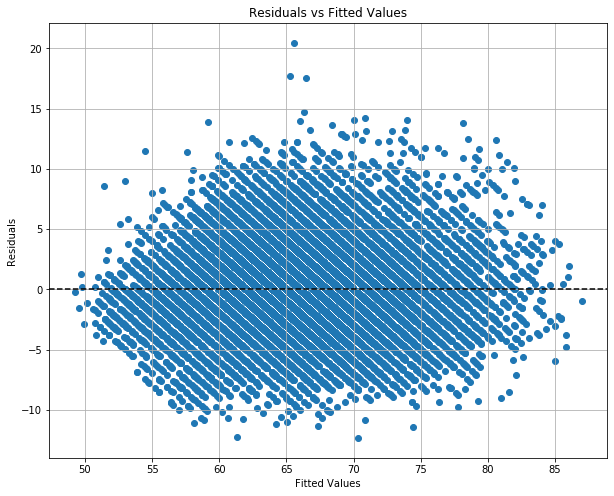

In [10]:
# Multiple Linear Regression (StatsModels)

# Calculate residuals and fitted values
fitted_values = rank.fittedvalues
residuals = rank.resid

# Plot Residuals vs Fitted values
plt.figure(figsize=(10, 8))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()

There are some issues. The values are clustered together, rather than scattered. This could mean that the model is non-linear. There seems to be more positive residuals than negative residuals, meaning there are more points above zero. There are also large outliers between 65 and 70. 

(c) The R-squared value is .705. 70.5% of the variation in rank is explained by these attributes: passing, attacking, defending, and skill. 30% of the variation in rank is unexplained. 

(d) Holding passing, attacking, and defending constant, a 1-unit increase in “skill” is associated with a 0.0066 increase in rank. 

(e) The formula for confidence interval is X̄ ± (SE*t-score). We use the t-score because we do not know the population standard deviation. The OLS regression table already calculated the 95% confidence interval for skill: [-0.011,	0.024]. 

(f) The p-value for skill is 0.465. This is not statistically significant at the 5% level. Also, the interval indicates that with a 1-unit increase in skill, there could be a change anywhere between a decrease by 0.011 units or an increase 0.024 units. It is important to note that zero is included in the confidence interval. Given that a 1-unit increase in skill could either be a positive, negative or no change and that the p-value is not statistically significant, we do not have enough evidence to determine the effect that skill has on a player's ranking. 

Problem 3

(a) These four feature (passing, attacking, defending, and skill) will do a pretty good job at predicting rank for out-of-sample data. This is because the R-squared value is 0.705. The model is a pretty good predictor. It explains 70.5% of the variance of an individuals rank. The adjusted R-square is still 0.705, which indicates that the model is not including too many irrelevant predictors. Also, the F-statistic is a fairly large number. This statistic tests the null hypothesis--all coefficients are equal to zero. A large F-statistic tells us that the predictor variables improve the prediction of the data. The p value of the F-statistic is 0.00. This tells us that the model is statistically significant. Therefore, the model, with all independent variables, does a pretty good job at predicting an individual player's rank. Although, it is worth mentioning that there are some issues with the model. The coefficients of passing, attacking, and defending all have a p value that is statistically significant at the 5% level. However, skill has a large p-value and a very small coefficient, which suggests it has limited predictive power. 

In [14]:
X = fifa_clean[['passing', 'attacking', 'defending', 'skill']]
Y = fifa_clean[['rank']]
X.head()

,passing,attacking,defending,skill
0,91.0,85.8,26.333333,94.0
1,70.0,69.0,89.000000,62.2
2,75.0,86.0,25.000000,79.0
3,62.0,62.6,91.333333,67.8
4,79.0,86.0,32.000000,81.4


In [15]:
Y.head()

,rank
0,93
1,92
2,92
3,92
4,92


(c)

In [30]:
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.25, random_state=123)
X_train.head()

,passing,attacking,defending,skill
17226,52.0,48.0,59.333333,53.2
13548,48.0,55.0,12.666667,54.0
17874,59.0,46.2,58.000000,57.8
19599,47.0,40.6,46.666667,40.0
15629,49.0,51.8,25.666667,49.6


(d)

In [27]:
model_sk = LinearRegression()
model_sk.fit(X_train, Y_train)

print("Coefficients of trained model;", model_sk.coef_)
print("Intercept of trained model;", model_sk.intercept_)

Coefficients of trained model; [[-0.02444506  0.61230756  0.17314968  0.00612364]]
Intercept of trained model; [25.16773306]


(e) The coefficient for attacking in the SKLearn model is 0.6123. While the coefficient for attacking in the statsmodel is 0.6109. This is a 0.0014 difference in coefficients. The change in coefficients is minimal. This implies that both models similarly estimate the effect that attacking has on rank. Both models believe that there is a ~0.61 increase in ranking when attacking increases by one unit. It being that the two models have the similar predictors reinforces the idea that the estimated effect of attacking on rank is accurate. For passing, the SKLearn model is -0.02445 and the statsmodel is -0.0247. The SKLearn model and the statsmodel for defending is 0.1731 and .1719, respectively. Finally, the SKLearn model and the statsmodel for skill is 0.00612 and .0066, respectively. All the coefficients do not differ that much between models. Which, once again, emphasizes the point that these features of a player that effect rank are accurately predicted.

(f)

In [37]:
y_pred = model_sk.predict(X_valid)
print("First three predicted values:", y_pred[:3])

First three predicted values: [[64.57617047]
 [72.78035994]
 [70.46341746]]


(g)

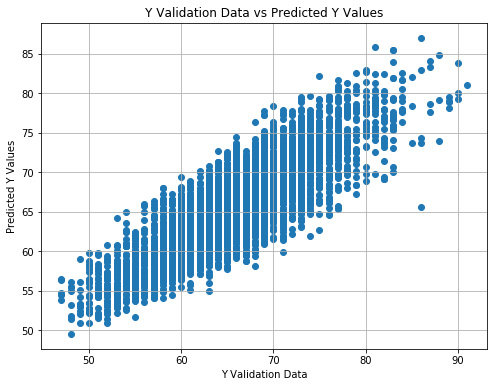

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_valid, y_pred)
plt.xlabel('Y Validation Data')
plt.ylabel('Predicted Y Values')
plt.title('Y Validation Data vs Predicted Y Values')
plt.grid(True)
plt.show()

(h)

In [44]:
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred)):.4f}")

RMSE: 3.7446


On average, the predicted values deviate from the actual values by 3.7446 units. This means that the model is typically off by 3-4 rankings for each player. This is a pretty good estimate of a player's ranking given that we have over 17,000 observations. 

(i) Overall, the model does a good job at predicting a player's rank. The model explains 70.5% of variance in a player's ranking. The root means squared error is 3.7446, which means it is off by 3.7446 rankings on average. Since the model is dealing with 17450 observations, that is pretty accurate. The F-statistic and most coefficients have a p-value less than 0.05, which informs us that the model is of statistical importance. The magnitude of the coefficients are relatively large for attacking, passing, and defending. Which means that the model does have an actual effect on a player's ranking. All of which suggests that overall, the model does a good job at predicting a player's ranking. 

Problem 4

(a)

In [46]:
preferred_foot_counts = fifa_clean['preferred_foot'].value_counts()
print(preferred_foot_counts)

Right    13044
Left      4406
Name: preferred_foot, dtype: int64


(b)

Player's prefer to use their right foot 74.8% of the time. If we were to build a classifier which always guessed a player preferred their
right foot, we would make a correct classification around 75% of the time.

(c)

In [47]:
X = fifa_clean[["shooting", "passing", "dribbling", "attacking", "defending", "skill", "movement", "power", "mentality", "goalkeeping"]]
X.head()

,shooting,passing,dribbling,attacking,defending,skill,movement,power,mentality,goalkeeping
0,92.0,91.0,95.0,85.8,26.333333,94.0,90.2,77.8,73.833333,10.8
1,61.0,70.0,81.0,69.0,89.000000,62.2,84.2,78.8,69.166667,12.6
2,93.0,75.0,88.0,86.0,25.000000,79.0,80.6,84.0,70.833333,15.6
3,70.0,62.0,73.0,62.6,91.333333,67.8,64.0,82.4,73.500000,12.8
4,92.0,79.0,86.0,86.0,32.000000,81.4,81.6,84.8,80.666667,10.2


(d)

In [50]:
sc = StandardScaler()    

x_rescale = pd.DataFrame(sc.fit_transform(X), columns = X.columns)
x_rescale.head(3)


,shooting,passing,dribbling,attacking,defending,skill,movement,power,mentality,goalkeeping
0,2.784312,3.296642,3.315358,3.400164,-1.393049,3.548580,2.774640,1.944282,2.180614,0.281676
1,0.597719,1.229719,1.876719,1.593417,2.131667,0.598209,2.072809,2.066501,1.623697,1.481100
2,2.854847,1.721843,2.596039,3.421673,-1.468043,2.156896,1.651710,2.702042,1.822596,3.480141


In [51]:
Y = fifa_clean['preferred_foot']
X_train, X_test, Y_train, Y_test = train_test_split(x_rescale, Y, test_size=0.3, random_state=456)
X_train.head(3)

,shooting,passing,dribbling,attacking,defending,skill,movement,power,mentality,goalkeeping
15473,-2.012086,-1.427753,-1.514357,-1.826497,0.444303,-1.572819,-0.968460,-1.013424,-1.558684,0.548214
9895,-0.460310,0.343895,0.746361,-0.277857,0.425554,0.616765,0.692541,-0.646766,-0.305621,-0.251402
12369,0.315578,0.147045,0.129801,0.087794,-0.886840,0.004424,-0.056079,-0.402328,-0.365291,-1.850634


(f)

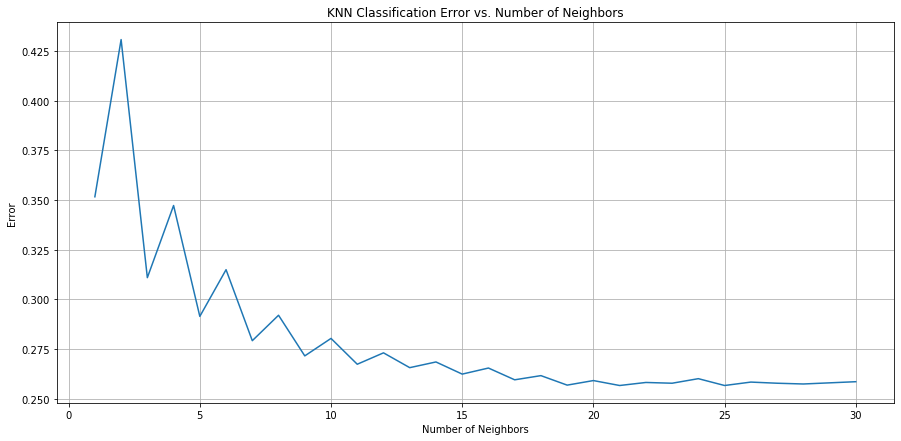

In [87]:
errors = [] 

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    error = 1 - knn.score(X_test, Y_test)
    errors.append(error)

fig = plt.figure(figsize=(15,7))
plt.plot(range(1,31), errors)
plt.title('KNN Classification Error vs. Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Error')
plt.grid(True)
plt.show()

(g)

In [92]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, Y_train)
Y_pred = knn.predict(X_test)
print("Preferred Foot Predictions:", Y_pred[:10])

Preferred Foot Predictions: ['Right' 'Right' 'Right' 'Right' 'Right' 'Right' 'Left' 'Left' 'Right'
 'Right']


(h)

In [95]:
confusion_matrix = confusion_matrix(Y_test, Y_pred)
print(confusion_matrix)

[[ 223 1103]
 [ 365 3544]]


There are a total of (1326 = 223 + 1103) true-left players. 1103 true left players were predicted to prefer their right foot. 

(i)

In [101]:
report = classification_report(Y_test, Y_pred)
print(report)

              precision    recall  f1-score   support

        Left       0.38      0.17      0.23      1326
       Right       0.76      0.91      0.83      3909

    accuracy                           0.72      5235
   macro avg       0.57      0.54      0.53      5235
weighted avg       0.67      0.72      0.68      5235



The recall for the classification “Left” suggest that our model is terrible at predicting preferred left players. Only 17% of true-left players were accurately predicted. 

(j) This model does a bad job at predicting a player’s preferred foot. It has a huge bias towards predicting that a player is right-footed. It predicts that a left-footed player is right-footed 83% of the time. The overall accuracy is 72%. Which is not bad if you were not to take into account that a left-footed player is rarely predicted correctly. This model is not reliable. 